Le but de cet projet est de prédire les fluctuations du cours de la bourse de deux manières. Premièrement, il s'agit de prédire, à partir de données telles que le volume d'échange, les prix les plus hauts/bas et le prix à l'ouverture, si le prix des actions va augmenter ou baisser. La deuxième méthode consiste à créer des séries temporelles en utilisant comme paramètre d'entrée le prix de clôture de l'action.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/fichier_sortie.csv"


In [3]:
# Importer les bibliothèques
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras import models,optimizers,layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [4]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, LeakyReLU, Activation
from tensorflow.keras.layers import BatchNormalization, Concatenate, Dropout
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import load_img
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from os import listdir
from numpy import asarray, load
from numpy import vstack
from numpy import savez_compressed
from matplotlib import pyplot
import numpy as np
from matplotlib import pyplot as plt
from numpy.random import randint
from numpy import zeros
from numpy import ones

Dans la première partie, l'objectif est de prédire les mouvements du cours de la bourse en utilisant des données d'entrée telles que le prix le plus haut, le prix le plus bas et le prix à l'ouverture. Trois architectures seront explorées : les réseaux de neurones récurrents (RNN), les réseaux de mémoire à court et long terme (LSTM) et les réseaux de neurones convolutifs unidimensionnels (1DCNN). Ensuite, le meilleur modèle sera sélectionné pour effectuer les tests finaux.

In [5]:
df = pd.read_csv(file_name)
#date en index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<ipython-input-5-1d31dde8a680>:3: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


In [6]:
# Préparer les données pour l'entraînement du modèle
x=df[['Low','Open','High','Close']]
y=df['Resultat']
x = np.array(x)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)


(4643, 4) (1161, 4) (4643,) (1161,)


Modèle de RNN

In [7]:
modelRNN = models.Sequential()
modelRNN.add(SimpleRNN(128,activation='relu', input_shape=(4,1)))
modelRNN.add(layers.BatchNormalization())
modelRNN.add(layers.Dropout(0.5))
modelRNN.add(layers.Dense(1, activation='sigmoid'))
modelRNN.compile(loss='binary_crossentropy',optimizer='SGD',metrics=['accuracy'])

In [8]:
# Entraîner le modèle RNN
results=modelRNN.fit(X_train,y_train, epochs=20,batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
146/146 [==============================] - 6s 16ms/step - loss: 0.7658 - accuracy: 0.4982 - val_loss: 0.7050 - val_accuracy: 0.4720
Epoch 2/20
146/146 [==============================] - 1s 6ms/step - loss: 0.7304 - accuracy: 0.5064 - val_loss: 0.7058 - val_accuracy: 0.4729
Epoch 3/20
146/146 [==============================] - 1s 5ms/step - loss: 0.7156 - accuracy: 0.5038 - val_loss: 0.6966 - val_accuracy: 0.5090
Epoch 4/20
146/146 [==============================] - 1s 5ms/step - loss: 0.7019 - accuracy: 0.5169 - val_loss: 0.6936 - val_accuracy: 0.5271
Epoch 5/20
146/146 [==============================] - 1s 5ms/step - loss: 0.7010 - accuracy: 0.5124 - val_loss: 0.6905 - val_accuracy: 0.5383
Epoch 6/20
146/146 [==============================] - 1s 5ms/step - loss: 0.6958 - accuracy: 0.5225 - val_loss: 0.6912 - val_accuracy: 0.5228
Epoch 7/20
146/146 [==============================] - 1s 6ms/step - loss: 0.6948 - accuracy: 0.5178 - val_loss: 0.7003 - val_accuracy: 0.5263
Epoch

In [9]:
print(results)
print(modelRNN.predict(X_train))

146/146 [==============================] - 1s 3ms/step
[[0.4640544 ]
 [0.46658903]
 [0.46368465]
 ...
 [0.4613178 ]
 [0.46270126]
 [0.463571  ]]


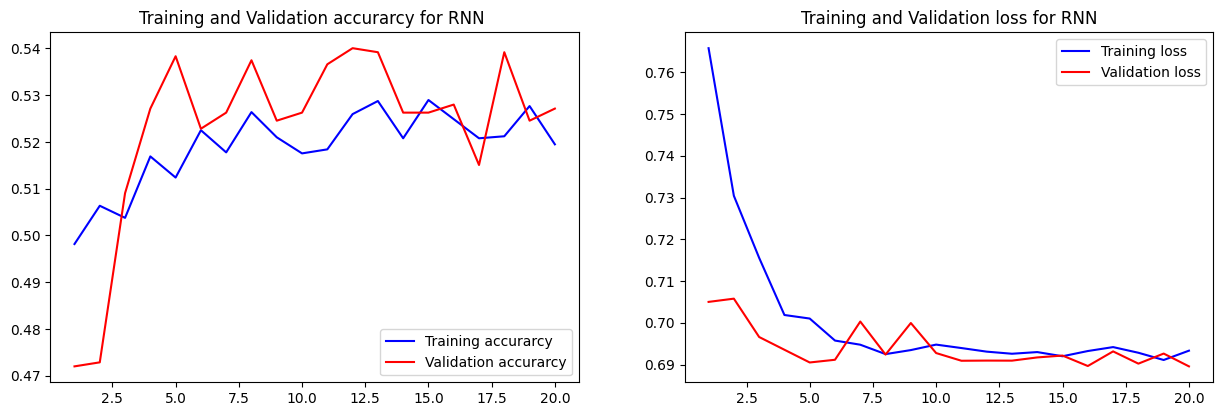

In [10]:
acc = results.history['accuracy']
val_acc =results.history['val_accuracy']
loss = results.history['loss']
val_loss = results.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy for RNN ')
plt.legend()
plt.subplot(2,2,2)
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss for RNN')
plt.legend()
plt.show()

Model LSTM

In [11]:
modelLSTM= tf.keras.Sequential()
modelLSTM.add(layers.LSTM(128, activation="relu", return_sequences=True, input_shape=(4,1)))
modelLSTM.add(layers.BatchNormalization())
modelLSTM.add(layers.Dropout(.5))
modelLSTM.add(layers.LSTM(64, activation="tanh", return_sequences=False))
modelLSTM.add(layers.BatchNormalization())
modelLSTM.add(layers.Dropout(.5))
modelLSTM.add(layers.Dense(1, activation="sigmoid"))
modelLSTM.summary()
modelLSTM.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            66560     
                                                                 
 batch_normalization_1 (Bat  (None, 4, 128)            512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 batch_normalization_2 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 64)               

In [12]:
# Entraîner le modèle RNN
resultslstm=modelLSTM.fit(X_train,y_train, epochs=50,batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
146/146 [==============================] - 10s 29ms/step - loss: 0.9188 - accuracy: 0.5085 - val_loss: 0.7039 - val_accuracy: 0.5168
Epoch 2/50
146/146 [==============================] - 3s 17ms/step - loss: 0.8257 - accuracy: 0.5104 - val_loss: 0.7113 - val_accuracy: 0.5271
Epoch 3/50
146/146 [==============================] - 2s 16ms/step - loss: 0.7795 - accuracy: 0.5154 - val_loss: 0.7016 - val_accuracy: 0.5271
Epoch 4/50
146/146 [==============================] - 2s 17ms/step - loss: 0.7603 - accuracy: 0.4977 - val_loss: 0.6923 - val_accuracy: 0.5297
Epoch 5/50
146/146 [==============================] - 3s 20ms/step - loss: 0.7345 - accuracy: 0.5042 - val_loss: 0.6885 - val_accuracy: 0.5401
Epoch 6/50
146/146 [==============================] - 4s 26ms/step - loss: 0.7193 - accuracy: 0.5098 - val_loss: 0.6916 - val_accuracy: 0.5228
Epoch 7/50
146/146 [==============================] - 3s 22ms/step - loss: 0.7072 - accuracy: 0.5143 - val_loss: 0.6897 - val_accuracy: 0.539

In [13]:
print(results)
print(modelLSTM.predict(X_train))

146/146 [==============================] - 1s 6ms/step
[[0.5178313 ]
 [0.70502657]
 [0.9345077 ]
 ...
 [0.04808032]
 [0.17992312]
 [0.25372303]]


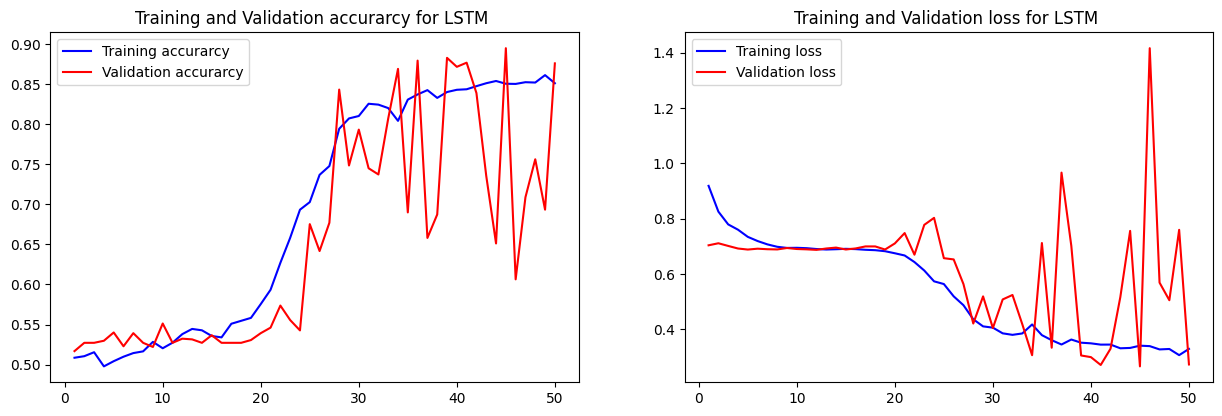

In [14]:
acc = resultslstm.history['accuracy']
val_acc =resultslstm.history['val_accuracy']
loss = resultslstm.history['loss']
val_loss = resultslstm.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy for LSTM ')
plt.legend()
plt.subplot(2,2,2)
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss for LSTM ')
plt.legend()
plt.show()

Model CNN

In [15]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Embedding

In [16]:
# Création du modèle 1D CNN
modelcnn = Sequential()
modelcnn.add(Embedding(input_dim=1000, output_dim=32, input_length=4))  # Couche d'embedding
modelcnn.add(Conv1D(64, 3, activation='relu'))  # Couche de convolution 1D avec 64 filtres et fenêtre de taille 3
modelcnn.add(MaxPooling1D(2))  # Couche de pooling
modelcnn.add(GlobalAveragePooling1D())  # Réduction dimensionnelle
modelcnn.add(Dense(1, activation='sigmoid'))  # Couche de sortie pour la classification binaire
modelcnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
# Entraîner le modèle RNN
resultscnn=modelcnn.fit(X_train,y_train, epochs=20,batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
146/146 [==============================] - 2s 5ms/step - loss: 0.6885 - accuracy: 0.5477 - val_loss: 0.6854 - val_accuracy: 0.5521
Epoch 2/20
146/146 [==============================] - 1s 4ms/step - loss: 0.6660 - accuracy: 0.6237 - val_loss: 0.6637 - val_accuracy: 0.6167
Epoch 3/20
146/146 [==============================] - 1s 6ms/step - loss: 0.6151 - accuracy: 0.6888 - val_loss: 0.6092 - val_accuracy: 0.6624
Epoch 4/20
146/146 [==============================] - 1s 6ms/step - loss: 0.5549 - accuracy: 0.7103 - val_loss: 0.5695 - val_accuracy: 0.6718
Epoch 5/20
146/146 [==============================] - 1s 6ms/step - loss: 0.5102 - accuracy: 0.7148 - val_loss: 0.5443 - val_accuracy: 0.6787
Epoch 6/20
146/146 [==============================] - 1s 7ms/step - loss: 0.4821 - accuracy: 0.7329 - val_loss: 0.5329 - val_accuracy: 0.6908
Epoch 7/20
146/146 [==============================] - 1s 6ms/step - loss: 0.4607 - accuracy: 0.7344 - val_loss: 0.5245 - val_accuracy: 0.6908
Epoch 

In [18]:
print(resultscnn)
print(modelcnn.predict(X_train))

146/146 [==============================] - 0s 3ms/step
[[0.6886273 ]
 [0.73056006]
 [0.2602101 ]
 ...
 [0.01148827]
 [0.5794152 ]
 [0.2338158 ]]


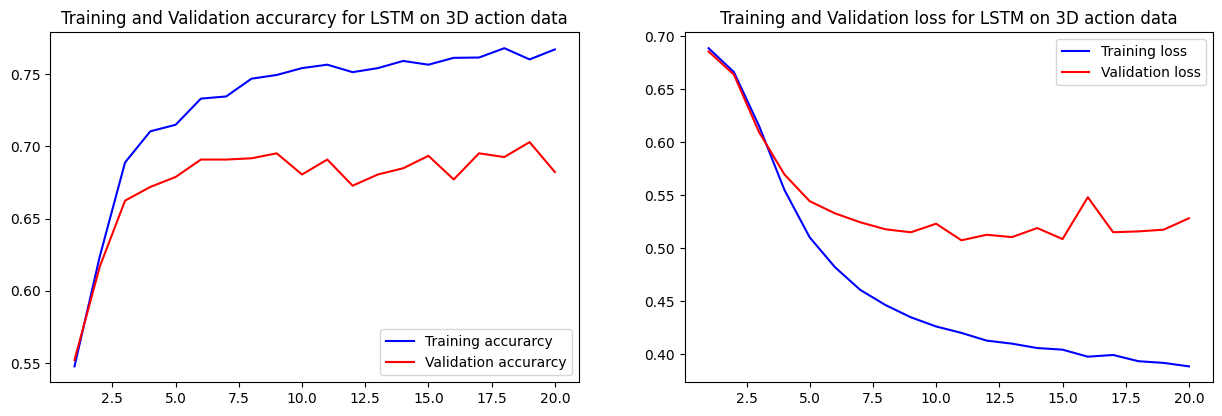

In [19]:
acc = resultscnn.history['accuracy']
val_acc =resultscnn.history['val_accuracy']
loss = resultscnn.history['loss']
val_loss = resultscnn.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy for CNN')
plt.legend()
plt.subplot(2,2,2)
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss for CNN')
plt.legend()
plt.show()

Prédiction avec des time série Modèle  LSTM et CNN

Prédiction avec des time série Modèle LSTM

In [20]:
data = pd.read_csv(file_name)
x=data.reset_index()['Close']

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler()
train_data= scaler.fit_transform(np.array(x).reshape(-1,1))
train_data.shape

(5804, 1)

In [23]:
def create_dataset(dataset,time_step = 1):
    dataX,dataY = [],[]
    for i in range(len(dataset)-time_step-1):
                   a = dataset[i:(i+time_step),0]
                   dataX.append(a)
                   dataY.append(dataset[i + time_step,0])
    return np.array(dataX),np.array(dataY)

print(X_train.shape)
print(X_train)
print(X_test.shape)
print(Y_test.shape)

In [24]:
# calling the create dataset function to split the data into
# input output datasets with time step 100
time_step = 100
X_train,Y_train =  create_dataset(train_data,time_step)

In [25]:
print(X_train.shape)

(5703, 100)


In [26]:
RNN  = tf.keras.Sequential()
RNN.add(layers.LSTM(128, activation="tanh", return_sequences=True, input_shape=(100,1)))
RNN.add(layers.BatchNormalization())
RNN.add(layers.Dropout(.5))
RNN.add(layers.LSTM(64, activation="tanh", return_sequences=False))
RNN.add(layers.BatchNormalization())
RNN.add(layers.Dense(32, activation="tanh"))
RNN.add(layers.Dropout(.5))
RNN.add(layers.Dense(1, activation="sigmoid"))
RNN.summary()
RNN.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 100, 128)          66560     
                                                                 
 batch_normalization_3 (Bat  (None, 100, 128)          512       
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 100, 128)          0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 batch_normalization_4 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 32)               

In [27]:
# Entraîner le modèle RNN
results=RNN.fit(X_train,Y_train, epochs=20,batch_size=32)

Epoch 1/20
179/179 [==============================] - 47s 231ms/step - loss: 0.4764 - accuracy: 3.5069e-04
Epoch 2/20
179/179 [==============================] - 44s 247ms/step - loss: 0.4329 - accuracy: 3.5069e-04
Epoch 3/20
179/179 [==============================] - 41s 230ms/step - loss: 0.4213 - accuracy: 3.5069e-04
Epoch 4/20
179/179 [==============================] - 45s 253ms/step - loss: 0.4176 - accuracy: 3.5069e-04
Epoch 5/20
179/179 [==============================] - 44s 245ms/step - loss: 0.4155 - accuracy: 3.5069e-04
Epoch 6/20
179/179 [==============================] - 41s 231ms/step - loss: 0.4161 - accuracy: 3.5069e-04
Epoch 7/20
179/179 [==============================] - 46s 258ms/step - loss: 0.4151 - accuracy: 3.5069e-04
Epoch 8/20
179/179 [==============================] - 44s 244ms/step - loss: 0.4142 - accuracy: 3.5069e-04
Epoch 9/20
179/179 [==============================] - 42s 232ms/step - loss: 0.4136 - accuracy: 3.5069e-04
Epoch 10/20
179/179 [================

In [28]:
print(RNN.predict(X_train))

179/179 [==============================] - 16s 81ms/step
[[0.4073765 ]
 [0.38583246]
 [0.3712356 ]
 ...
 [0.82081187]
 [0.821758  ]
 [0.82416826]]


Prédiction avec des time série Modèle  1D CNN

In [34]:
# Création du modèle 1D CNN
CNN= Sequential()
CNN.add(Embedding(input_dim=100, output_dim=32, input_length=100))  # Couche d'embedding
CNN.add(Conv1D(64, 3, activation='relu'))  # Couche de convolution 1D avec 64 filtres et fenêtre de taille 3
CNN.add(MaxPooling1D(2))  # Couche de pooling
CNN.add(GlobalAveragePooling1D())  # Réduction dimensionnelle
CNN.add(Dense(1, activation='sigmoid'))  # Couche de sortie pour la classification binaire
CNN.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [35]:
resultsCNN=CNN.fit(X_train,Y_train, epochs=20,batch_size=32)

Epoch 1/20
179/179 [==============================] - 7s 16ms/step - loss: 0.5400 - accuracy: 1.7535e-04
Epoch 2/20
179/179 [==============================] - 3s 17ms/step - loss: 0.5201 - accuracy: 1.7535e-04
Epoch 3/20
179/179 [==============================] - 3s 16ms/step - loss: 0.5136 - accuracy: 1.7535e-04
Epoch 4/20
179/179 [==============================] - 3s 18ms/step - loss: 0.5053 - accuracy: 1.7535e-04
Epoch 5/20
179/179 [==============================] - 4s 20ms/step - loss: 0.5044 - accuracy: 1.7535e-04
Epoch 6/20
179/179 [==============================] - 4s 24ms/step - loss: 0.5042 - accuracy: 1.7535e-04
Epoch 7/20
179/179 [==============================] - 3s 18ms/step - loss: 0.5041 - accuracy: 1.7535e-04
Epoch 8/20
179/179 [==============================] - 3s 15ms/step - loss: 0.5043 - accuracy: 1.7535e-04
Epoch 9/20
179/179 [==============================] - 3s 19ms/step - loss: 0.5042 - accuracy: 1.7535e-04
Epoch 10/20
179/179 [==============================] - 

In [36]:
print(CNN.predict(X_train))

179/179 [==============================] - 1s 4ms/step
[[0.20475236]
 [0.20475236]
 [0.20475236]
 ...
 [0.20475236]
 [0.20475236]
 [0.20475236]]


 Prédiction avec des time série Modèle Arima

In [37]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

In [38]:
df = pd.read_csv(file_name)
#date en index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<ipython-input-38-1d31dde8a680>:3: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


In [39]:
# Entraînement du modèle ARIMA
model = sm.tsa.ARIMA(df['Resultat'], order=(1, 1, 1))
results = model.fit()

# Afficher les résultats de la modélisation
print(results.summary())
#predictiion de la dernier journée enregistrés  et de 3 prochains jours
forecast = results.forecast(steps=4)
print(forecast)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:               Resultat   No. Observations:                 5804
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4208.268
Date:                Tue, 14 Nov 2023   AIC                           8422.535
Time:                        00:42:37   BIC                           8442.534
Sample:                             0   HQIC                          8429.492
                               - 5804                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0026      0.013     -0.200      0.841      -0.028       0.023
ma.L1         -0.9987      0.001  -1085.384      0.000      -1.001      -0.997
sigma2         0.2494      0.055      4.552      0.0

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [82]:
def prediction_RNN(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df.set_index('Date', inplace=True)
  x=df[['Low','Open','Volume','High','Close']]
  y=df['Resultat']
  x = np.array(x)
  y = np.array(y)
  X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
  a=X_train.shape
  a=a[0]
  i=0
  resultat=[]
  while i<10:
   mdl=modelRNN.predict(X_train[[i]])
   if (mdl>=0.47):
    resultat.append(1)
   else:
    resultat.append(0)
   i=i+1
  return resultat

def prediction_LSTM(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df.set_index('Date', inplace=True)
  x=df[['Low','Open','High','Close']]
  y=df['Resultat']
  x = np.array(x)
  y = np.array(y)
  X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
  a=X_train.shape
  a=a[0]
  i=0
  resultat=[]
  while i<10:
   mdl=modelLSTM.predict(X_train[[i]])
   if (mdl>=0.5):
    resultat.append(1)
   else:
    resultat.append(0)
   i=i+1
  return resultat

def prediction_CNN(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df.set_index('Date', inplace=True)
  x=df[['Low','Open','High','Close']]
  y=df['Resultat']
  x = np.array(x)
  y = np.array(y)
  X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
  a=X_train.shape
  a=a[0]
  i=0
  resultat=[]
  while i<10:
   mdl=modelcnn.predict(X_train[[i]])
   if (mdl>=0.5):
    resultat.append(1)
   else:
    resultat.append(0)
   i=i+1
  return resultat

In [84]:
data = pd.read_csv(file_name)
a=prediction_CNN(data)

print("resultat_CNN=",a)

data.head(10)

<ipython-input-82-df01819b9f4e>:44: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


1/1 [==============================] - 0s 23ms/step
resultat_CNN= [1, 1, 1, 1, 0, 0, 0, 1, 0, 1]


,Low,Open,Volume,High,Close,Adjusted Close,Nom,A,Resultat
Date,,,,,,,,,
1999-11-18,28.612303,32.546494,62546380,35.765381,31.473534,26.929760,A,NaN,1
1999-11-19,28.478184,30.713518,15234146,30.758226,28.880545,24.711119,A,NaN,1
1999-11-22,28.657009,29.551144,6577870,31.473534,31.473534,26.929760,A,NaN,0
1999-11-23,28.612303,30.400572,5975611,31.205294,28.612303,24.481602,A,NaN,1
1999-11-24,28.612303,28.701717,4843231,29.998213,29.372318,25.131901,A,NaN,0
1999-11-26,29.148785,29.238197,1729466,29.685265,29.461731,25.208408,A,NaN,0
1999-11-29,29.014664,29.327612,4074751,30.355865,30.132332,25.782187,A,NaN,0
1999-11-30,29.282904,30.042917,4310034,30.713518,30.177038,25.820436,A,NaN,0
1999-01-12,29.953505,30.177038,2957329,31.071173,30.713518,26.279463,A,NaN,0


In [ ]:
def time_serie_LSTM():
  x=data.reset_index()['Close']
  from sklearn.preprocessing import MinMaxScaler
  scaler = MinMaxScaler()
  data = scaler.fit_transform(np.array(x).reshape(-1,1))
  data.shape
  train_size = int(len(x)*0.65)
  test_size = len(data) - train_size
  train_data,test_data = data[0:train_size,:],data[train_size:len(data),:1]
  def create_dataset(dataset,time_step = 1):
      dataX,dataY = [],[]
      for i in range(len(dataset)-time_step-1):
                    a = dataset[i:(i+time_step),0]
                    dataX.append(a)
                    dataY.append(dataset[i + time_step,0])
      return np.array(dataX),np.array(dataY)
  time_step = 100
  X_train,Y_train =  create_dataset(train_data,time_step)
  X_test,Y_test =  create_dataset(test_data,time_step)